In [4]:
from sklearn.datasets import make_classification

x, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.DataFrame(x, columns=['x1', 'x2'])

In [10]:
df['y'] = y
df['y'] = df['y'].replace(0, -1)

In [11]:
df

,x1,x2,y
0,1.689767,-1.408241,1
1,1.530287,-1.459848,1
2,-1.175042,-1.447633,-1
3,-2.585395,0.963532,-1
4,1.372246,0.440695,1
...,...,...,...
195,-0.435396,0.715716,-1
196,1.040417,1.108613,1
197,1.883798,0.782433,-1
198,1.829367,1.542978,1


In [12]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [13]:
x = df.iloc[: , 0:2]
y = df.iloc[: , -1]

In [16]:
x

,x1,x2
0,1.689767,-1.408241
1,1.530287,-1.459848
2,-1.175042,-1.447633
3,-2.585395,0.963532
4,1.372246,0.440695
...,...,...
195,-0.435396,0.715716
196,1.040417,1.108613
197,1.883798,0.782433
198,1.829367,1.542978


In [17]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,  y , test_size=0.2 , random_state=42)

In [18]:
x_train

,x1,x2
79,-0.182557,-2.461648
197,1.883798,0.782433
38,-1.092349,0.287622
24,-1.129710,-0.507833
122,-1.970049,1.507610
...,...,...
106,-1.209659,-1.277852
14,1.770796,1.535577
92,1.346412,-0.060801
179,-0.378923,-2.341745


In [19]:
clf = DecisionTreeClassifier(max_depth=1)

In [20]:
clf.fit(x_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred = clf.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.825

In [46]:
ada = AdaBoostClassifier(n_estimators=150 , learning_rate=0.1)

In [47]:
ada.fit(x_train , y_train)

,estimator,None
,n_estimators,150
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,None


In [34]:
y_pred2 = ada.predict(x_test)

In [35]:
accuracy_score(y_test , y_pred2)

0.825

<Axes: xlabel='x1', ylabel='x2'>

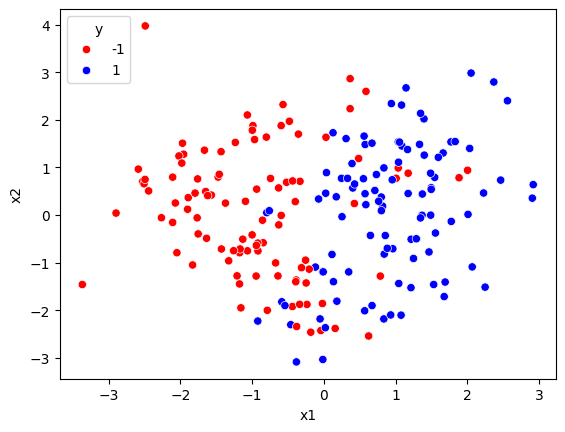

In [36]:
from mlxtend.plotting import plot_decision_regions

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['y'], palette=['red', 'blue'])

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


<Axes: >

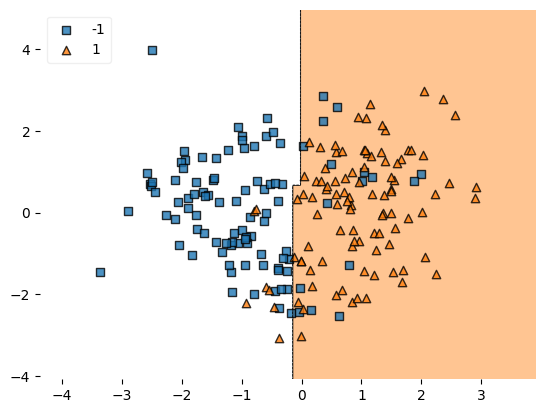

In [48]:
x =df.iloc[: , 0:2].values
y = df.iloc[: , -1].values
plot_decision_regions(x, y ,clf=ada , legend=2)

In [49]:
# n_estimators: Int = 50,
#     learning_rate: Float = 1,
#     algorithm: Literal['SAMME', 'SAMME.R'] = "SAMME.R",
#     random_state: Int | RandomState | None = None,
#     base_estimator: Any = "deprecated"
from sklearn.model_selection import GridSearchCV
grid = dict()
grid['n_estimators'] = [1 , 10 , 100 ,200 , 300 , 400 , 500]
grid['learning_rate'] = [0.001 , 0.01 , 0.1 , 1 , 10]
grid['algorithm'] = ['SAMME', 'SAMME.R']


In [51]:
ada2 = AdaBoostClassifier()
gd = GridSearchCV(ada2 , param_grid=grid , cv=5)

In [52]:
gd.fit(x_train , y_train)

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\en

,estimator,AdaBoostClassifier()
,param_grid,"{'algorithm': ['SAMME', 'SAMME.R'], 'learning_rate': [0.001, 0.01, ...], 'n_estimators': [1, 10, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [53]:
gd.best_score_

np.float64(0.89375)

In [54]:
gd.best_estimator_

,estimator,None
,n_estimators,1
,learning_rate,0.001
,algorithm,'SAMME'
,random_state,None
